<a href="https://colab.research.google.com/github/JuanJoboy/Introduction-to-Business-Programming/blob/main/Module%2008%20-%20API/lab_ticket_stock_chart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kevin-blasiak-curtin/ISYS2001-Archive/blob/main/Module%2008%20-%20API/lab_ticket_stock_chart.ipynb)

# Lab Ticket: Charting Real Stock Data

This week you used the Gemini API: you sent it text, and it sent text back. A stock service works the same way. You send a request (which company, what kind of data) and it sends back a structured response you can turn into a chart.

Your job is to fetch real stock data and draw one clear figure from it. The fetching is written for you. The figure is yours.

## The brief

**API to integrate:** Alpha Vantage (free).

Get your own key the same way you got your Gemini key:

1. Sign up at https://www.alphavantage.co/support/#api-key
2. Store it in Colab Secrets as `ALPHAVANTAGE_API_KEY`, with Notebook access switched on.

Use your own key, not the shared `demo` key. The demo key only ever returns data for IBM.

**Figure I expect:** a line chart of the daily closing price for one ticker of your choice, across the window the data covers. Label both axes, and give the chart a title that names the ticker.

**A note on limits:** the free key allows only about 25 requests a day. Run the fetch cell once. After that the data lives in a DataFrame called `prices`, so do all your charting from that. Re-running the fetch cell over and over will use up your daily quota, and you will start getting a notice instead of data.

In [3]:
from google.colab import userdata
import requests
import pandas as pd
import matplotlib.pyplot as plt

API_KEY = userdata.get("ALPHAVANTAGE_API_KEY")


def get_stock_data(ticker):
    """Fetch daily prices for a ticker and return a tidy DataFrame.

    The result has a date index and Open, High, Low, Close and Volume columns,
    sorted from oldest to newest.
    """
    url = "https://www.alphavantage.co/query"
    params = {
        "function": "TIME_SERIES_DAILY",
        "symbol": ticker,
        "apikey": API_KEY,
        "outputsize": "compact",   # the most recent 100 trading days
    }

    response = requests.get(url, params=params)
    data = response.json()

    # If the expected data is missing, Alpha Vantage explains why here: an
    # invalid ticker, a missing key, or a note that you have hit the daily limit.
    if "Time Series (Daily)" not in data:
        reason = (data.get("Error Message")
                  or data.get("Note")
                  or data.get("Information")
                  or data)
        raise ValueError(f"No price data returned. Alpha Vantage said: {reason}")

    prices = pd.DataFrame.from_dict(data["Time Series (Daily)"], orient="index")
    prices = prices.rename(columns={
        "1. open": "Open",
        "2. high": "High",
        "3. low": "Low",
        "4. close": "Close",
        "5. volume": "Volume",
    })
    prices = prices.astype(float)
    prices.index = pd.to_datetime(prices.index)
    prices = prices.sort_index()
    return prices

In [4]:
# Run this once. Change the ticker to one of your choice.
prices = get_stock_data("NVDA")
prices.tail()

,Open,High,Low,Close,Volume
2026-09-14,211.240,212.770,208.930,210.96,132267244.0
2026-09-15,213.375,213.940,211.160,212.17,88059658.0
2026-09-16,214.140,216.760,212.500,213.90,96563590.0
2026-09-17,218.375,219.905,217.145,219.34,94191263.0
2026-09-18,219.350,222.730,218.030,222.27,190287428.0


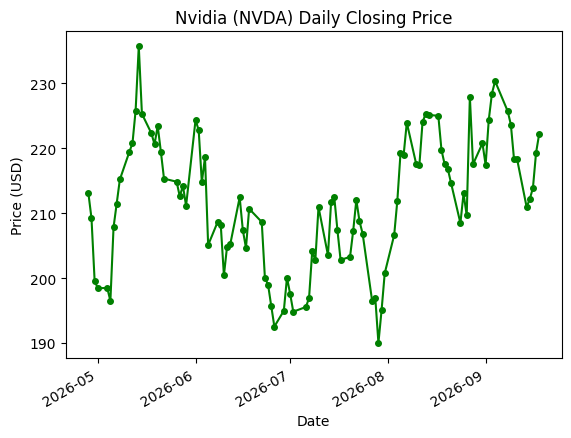

In [30]:
# Your chart from here.
# Draw the daily closing price as a labelled line chart, using the `prices` DataFrame.

try:
  # Pandas creates the plot
  prices['Close'].plot(color='green', marker='o', markersize=4)

  # Matplotlib configures the presentation
  plt.title("Nvidia (NVDA) Daily Closing Price")
  plt.xlabel("Date")
  plt.ylabel("Price (USD)")
  plt.show()
except ValueError as e:
  print(f"Mismatched data was encountered when plotting: {e}")
except TypeError as e:
    print(f"Data type error during plotting: {e}")
except Exception as e:
    print(f"Something went wrong when plotting your graph: {e}")
finally:
  plt.close('all')

## Before you finish

Be ready to explain, in your own words:

- what the fetch returns, and what a single row represents
- why a line chart suits this kind of data
- what your finished chart actually shows

**Stretch (optional):** add a second ticker to the same chart, or work out a simple moving average and plot it alongside the price. A moving average needs no extra request, since it is worked out from the data you already have.



### 1. What the fetch returns, and what a single row represents
- The fetch was an API call that grabbed a JSON object from https://www.alphavantage.co/query that contained key-value pairs for the following keys: Open, High, Low, Close, Volume. And these 5 keys are wrapped inside another key-value pair, with them being the value, and the key being the date (2026-09-14 for example). this is all then wrapped as a value inside another pair, with the key being `Time Series (Daily)`. A single row represents a single trading day containing the afformentioned values. The `get_stock_data()` function then ensures the data isn't malformed by first checking if the `Time Series (Daily)` key is in the dataset, and if it isn't then something went wrong. The data is then sorted chronologically by the days, and put into a DataFrame.

### 2. Why a line chart suits this kind of data
- A line chart suits this data as the available data follows the structure needed for a line chart. Stock prices are continuous time-series data, and a line chart can easily map these prices at each point in time on a graph that can be following from the starting time to the ending time. A bar or pie chart wouldn't show this continuous movement as clearly. A time variable is given which represents the X-axis easily, and any of the other pieces of information in the JSON fits onto the Y-axis, as they are the bits of data being observed.

### 3. What your finished chart actually shows
- The final chart shows the closing prices of the NVIDIA stock (in what I presume is USD) across time from 05/2026 to 09/2026. Each closing price is a circle for greater visibility, and the line is green to represent NVIDIA.